# Differential rules between conditions and tissue states

Advisor request #5: for each pair of groups, which rules are enriched or depleted in one group vs the other. Comparisons:
- **Colon vs Duodenum** (pooling all stages)
- **Within each organ:** Control vs Mild, Mild vs Severe, Severe vs Control

## Configuration & Constants
Same style as the other result-summary notebooks: everything to tune lives here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import sys
import ast
import warnings
warnings.filterwarnings('ignore')

# Add root to path for utils
sys.path.append(os.path.abspath('../..'))   # project root
sys.path.append(os.path.abspath('..'))          # shared helpers, one level up

# Shared loader + rule-name cleaning (also used by the other result-summary notebooks)
import data_helper as dh
from data_helper import base_items, clean_items, check_rule_overlap

In [2]:
# ==========================================
# CONFIGURATION & CONSTANTS
# ==========================================
# Which rules take part
RULE_MAX_ITEMS = 2          # pairwise only
NO_SELF        = True       # drop rules where a cell type repeats (Muscle -> Muscle)
KIND           = None        # 'attracts', 'avoids', or None for every rule

# How FOVs are grouped for the comparisons
SCORE_COLUMN = 'Pathological score'
STAGE_ORDER  = ['Control', 'Mild', 'Severe']     # the ordered severity axis
ORGAN_ORDER  = ['Colon', 'Duodenum']

# A rule needs at least this many total occurrences across the two compared groups
# combined before it is even tested - avoids spending an FDR 'slot' on a rule seen in
# only one or two FOVs. A rule absent from one whole group still passes this on its
# own (0 + enough-in-the-other-group), which is exactly the cleanest kind of gap.
MIN_FOVS_TOTAL = 3

# FDR cutoff used when reporting / plotting 'significant' differential rules
FDR_THRESHOLD = 0.05

# How big a gap is worth caring about, in percentage points. Nothing in the statistics
# can pick this number - it is a judgement call, so it sits here next to the rest.
# None = no gap cutoff, keep whatever the FDR lets through.
MIN_GAP = None

TOP_TREND_RULES = 15

## Load Data
The same loader and the same rule table as the other result-summary notebooks.

In [3]:
# Load cells, FOVs and biopsies (shared loader, see data_helper.py).
df_cells, df_fovs, df_biopsy = dh.load_spatial_data()

Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71


In [4]:
# Load the mined rules (already filtered to per-FOV FDR <= 0.05).
df_results = dh.load_results(rule_max_items=RULE_MAX_ITEMS, kind=KIND)

Read results_CN_pairwise.csv
Loaded 16600 rules.
Kept 9719 rules at FDR <= 0.05.
Kept 9719 rules that add information.
Kept 9719 rules (max_items=2, kind=None).


## Logic

In [5]:
def clean_rule_table(df_results, no_self=NO_SELF):
    """One row per rule per FOV, with the rule's name cleaned into one consistent
    form ('Clean_Rule') and that FOV's metrics.

    Cleaning = sorted, comma-joined cell-type names on each side (data_helper.clean_items),
    so the same rule always reads the same way however it was ordered when it was mined.
    'no_self' drops rules where a cell type repeats (e.g. Muscle -> Muscle).
    """
    df = df_results.copy()
    if no_self:
        overlap = df.apply(lambda r: check_rule_overlap(base_items(r['Antecedents']),
                                                         base_items(r['Consequents'])), axis=1)
        df = df[~overlap].copy()
    df['Clean_Ant'] = df['Antecedents'].apply(clean_items)
    df['Clean_Con'] = df['Consequents'].apply(clean_items)
    df['Clean_Rule'] = df['Clean_Ant'] + ' -> ' + df['Clean_Con']
    return df

rule_matrix = clean_rule_table(df_results)
print(f"{len(rule_matrix)} rule rows, {rule_matrix['Clean_Rule'].nunique()} distinct rules, "
      f"{rule_matrix['FOV'].nunique()} FOVs.")

8761 rule rows, 551 distinct rules, 288 FOVs.


In [6]:
def rule_presence(rule_matrix):
    """Rules x FOVs, three states: +1 the cell types attract, -1 they avoid, 0 nothing.

    Every row here already passed the per-FOV FDR <= 0.05 filter, so a -1 is a real
    avoidance, not a missing measurement. Telling -1 apart from 0 is the point: a rule
    can be missing from a group because nothing was found, or because the cells push
    apart there - opposite meanings that a yes/no matrix would merge.
    """

    state = np.where(rule_matrix['Lift'] > 1, 1, -1)

    matrix = (rule_matrix.assign(state=state)
              .pivot(index='Clean_Rule', columns='FOV', values='state')
              .fillna(0)
              .astype(int))

    return matrix

rule_presence_matrix = rule_presence(rule_matrix)

attract, avoid = rule_presence_matrix == 1, rule_presence_matrix == -1
print(f"presence matrix: {rule_presence_matrix.shape[0]} rules x {rule_presence_matrix.shape[1]} FOVs")
print(f"  attract: {attract.to_numpy().sum():5d} rule-FOV pairs, {attract.any(axis=1).sum():3d} rules")
print(f"  avoid  : {avoid.to_numpy().sum():5d} rule-FOV pairs, {avoid.any(axis=1).sum():3d} rules")

presence matrix: 551 rules x 288 FOVs
  attract:  3159 rule-FOV pairs, 330 rules
  avoid  :  5602 rule-FOV pairs, 374 rules


#### Cell abundance

In [7]:
def cell_share_matrix(df_cells):
    """Cell types x FOVs: what share of that FOV's cells each type makes up.

    Same shape as the rule matrix, so the very same comparison runs on it - the test
    only ever asks whether the numbers in one group sit higher than in the other.
    """
    counts = df_cells.groupby(['fov', 'cell type']).size().unstack(fill_value=0)
    return counts.div(counts.sum(axis=1), axis=0).T

cell_matrix = cell_share_matrix(df_cells)

### Comparision Code

In [8]:
def chance_of(values, weights, observed, n_perms=5000, seed=0):
    """How often chance alone gives a score at least this big, per rule.

    A score is `values @ weights`: every FOV's value times its weight, summed. The weights
    are what makes it a gap or a slope - the test itself does not care which. Shuffling
    the weights between the FOVs is the null: the groups were interchangeable all along.

    values — one number per rule per FOV (rules × FOVs matrix). Rule-specific.
    weights — one number per FOV (a single vector). 
                Every FOV in the same group gets the same value, so in practice it's "a group's number, repeated for its FOVs".
    observed : one per rule, the real score `values @ weights`
    """
    rng = np.random.default_rng(seed)

    # One column per shuffle: the same weights, dealt out to different FOVs.
    shuffled_weights = np.column_stack([rng.permutation(weights) for _ in range(n_perms)])

    # rules x shuffles - every rule scored against every shuffled world, in one product.
    null = values @ shuffled_weights

    # Same (better + 1) / (tries + 1) as the mining pipeline's own permutation test:
    # the +1 counts the real world as one of the tries, so a p-value is never exactly 0.
    beat_it = np.abs(null) >= np.abs(observed)[:, None] - 1e-12
    return (beat_it.sum(axis=1) + 1) / (n_perms + 1)

In [9]:
def group_values(matrix, fovs):
    """One group's columns as a plain float array; FOVs that were never seen count as 0."""
    return matrix.reindex(columns=fovs, fill_value=0).to_numpy(dtype=float)

In [10]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

def compare_groups(rule_presence_matrix, fovs_a, fovs_b, label_a, label_b,
                   min_fovs=MIN_FOVS_TOTAL):
    """
    Which rules differentiate group A from group B: prevalence gap + Fisher's
    exact test + FDR, one row per rule with enough FOVs in both groups combined.
    
    fovs_a, fovs_b   : the FOVs in each group (e.g. Control FOVs vs Severe FOVs).
    label_a, label_b : names for the two groups, used in the output column names.
    """

    a, b = group_values(rule_presence_matrix, fovs_a), group_values(rule_presence_matrix, fovs_b)

    keep = ((a != 0).sum(1) + (b != 0).sum(1)) >= min_fovs
    a, b, rules = a[keep], b[keep], rule_presence_matrix.index[keep]

    net_a, net_b = a.mean(1), b.mean(1) #  (attracts - avoids) / group size
    effect_size = net_a - net_b

    # These weights average A up and B down, so the score is the gap itself.
    weights = np.r_[np.full(a.shape[1], 1 / a.shape[1]),
                    np.full(b.shape[1], -1 / b.shape[1])]

    print("Compare - weights: ", weights)
    
    p_values = chance_of(np.hstack([a, b]), weights, effect_size)


    fdr = multipletests(p_values, method='fdr_bh')[1]
    result = pd.DataFrame({
        f'net_{label_a}': net_a,
        f'net_{label_b}': net_b,
        'effect_size': effect_size,
        f'n_attract_{label_a}': (a == 1).sum(1), f'n_avoid_{label_a}': (a == -1).sum(1),
        f'n_attract_{label_b}': (b == 1).sum(1), f'n_avoid_{label_b}': (b == -1).sum(1),
        'p_value': p_values,
        'fdr': fdr
    }, index=rules)

    return result.sort_values('effect_size', key = abs, ascending=False)  # largest gaps first

In [11]:
def mean_metrics_by_group(rule_matrix, fov_to_group, metrics=('Lift', 'Confidence')):
    """Each rule's typical Lift / Confidence per group, all groups side by side.

    Lift is a ratio - 0.5 is as far below 1 as 2.0 is above it - so it is averaged in
    log space and turned back, otherwise an avoidance and an attraction do not cancel.
    """
    df = rule_matrix.copy()
    df['Group'] = df['FOV'].map(fov_to_group)
    df['Lift'] = np.log(df['Lift'].clip(lower=1e-6))

    means = df.groupby(['Clean_Rule', 'Group'])[list(metrics)].mean()
    means['Lift'] = np.exp(means['Lift'])
    return means.unstack('Group')

In [12]:
def report_table(comparison, label_a, label_b, metrics = None, top_n=15, fdr_threshold=FDR_THRESHOLD):
    """The dumbbell's rows as a table: same rules, same order, plain column names.

    '+ / -' is how many FOVs of that group the pair attracted in / avoided in.
    """
    top = comparison.head(top_n)
    table = pd.DataFrame({
        f'{label_a} net %': (top[f'net_{label_a}'] * 100).round(1),
        f'{label_b} net %': (top[f'net_{label_b}'] * 100).round(1),
        'gap (pp)': (top['effect_size'] * 100).abs().round(1),
        'more in': np.where(top['effect_size'] > 0, label_a, label_b),
        f'{label_a} FOVs + / -': (top[f'n_attract_{label_a}'].astype(str) + ' / '
                                  + top[f'n_avoid_{label_a}'].astype(str)),
        f'{label_b} FOVs + / -': (top[f'n_attract_{label_b}'].astype(str) + ' / '
                                  + top[f'n_avoid_{label_b}'].astype(str)),
        'FDR': top['fdr'].round(4),
        'passed': np.where(top['fdr'] <= fdr_threshold, 'yes', 'no'),
    })

    if metrics is not None:
        means = metrics.sort_index(axis=1).loc[:, (slice(None), [label_a, label_b])]
        means.columns = [f'mean {metric} {group}' for metric, group in means.columns]
        table = table.join(means.round(2))
        
    return table

### Groups to Compare

In [13]:
def fovs_for(organ=None, stage=None):
    """FOV list for one organ, one stage, or both - whichever is given."""

    mask = pd.Series(True, index=df_fovs.index)
    if organ is not None:
        mask &= df_fovs['Organ'] == organ
    if stage is not None:
        mask &= df_fovs[SCORE_COLUMN] == stage

    return df_fovs.loc[mask, 'FOV'].tolist()

In [14]:
organ_comparision = compare_groups(rule_presence_matrix, fovs_for(organ='Colon'), fovs_for(organ='Duodenum'), 'Colon', 'Duodenum')

stage_pairs = [('Control', 'Mild'), ('Control', 'Severe'), ('Mild', 'Severe')]
stage_comparisions = {}

for organ in ORGAN_ORDER:
    for stage_a, stage_b in stage_pairs:
        stage_comparisions[(organ, stage_a, stage_b)] = compare_groups(
            rule_presence_matrix, fovs_for(organ=organ, stage=stage_a), fovs_for(organ=organ, stage=stage_b), f"{stage_a}", f"{stage_b}"
        )

Compare - weights:  [ 0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.010

In [15]:
organ_metrics = mean_metrics_by_group(rule_matrix, df_fovs.set_index('FOV')['Organ'])
stage_metrics = mean_metrics_by_group(rule_matrix, df_fovs.set_index('FOV')[SCORE_COLUMN])

In [16]:
organ_cells = compare_groups(cell_matrix, fovs_for(organ='Colon'),
                             fovs_for(organ='Duodenum'), 'Colon', 'Duodenum')

stage_cells = {}
for organ in ORGAN_ORDER:
    for stage_a, stage_b in stage_pairs:
        stage_cells[(organ, stage_a, stage_b)] = compare_groups(
            cell_matrix, fovs_for(organ=organ, stage=stage_a),
            fovs_for(organ=organ, stage=stage_b), stage_a, stage_b)

Compare - weights:  [ 0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928  0.01030928
  0.01030928  0.01030928  0.010

## Plots

Two views per comparison. The **volcano** is the whole picture: every tested rule at
once, how big its gap is and how sure we are. The **dumbbell** zooms in on the rules
that differ most and names them, with how often each shows up in each group.

In [17]:
import differential_vis as dv

### Colon vs Duodenum

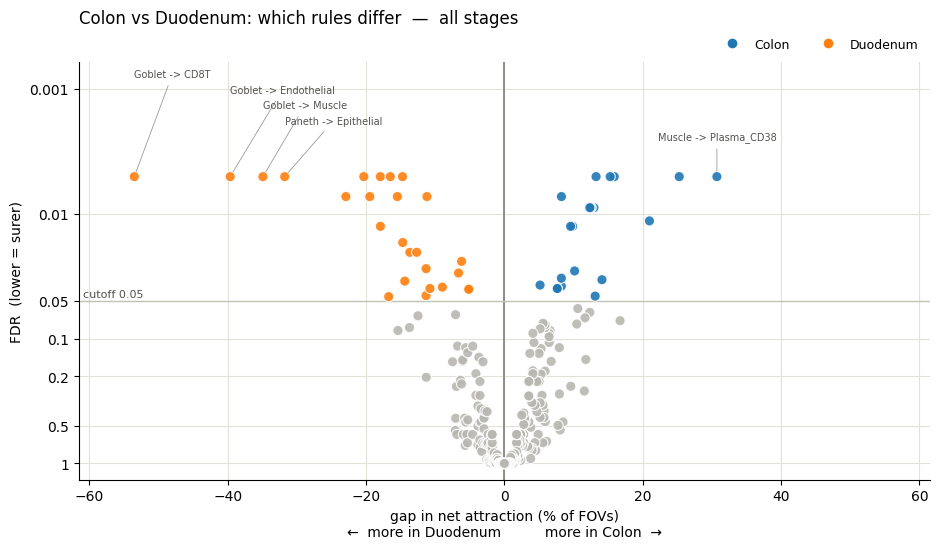

In [18]:
dv.plot_volcano(organ_comparision, 'Colon', 'Duodenum', scope='all stages', min_gap=MIN_GAP)

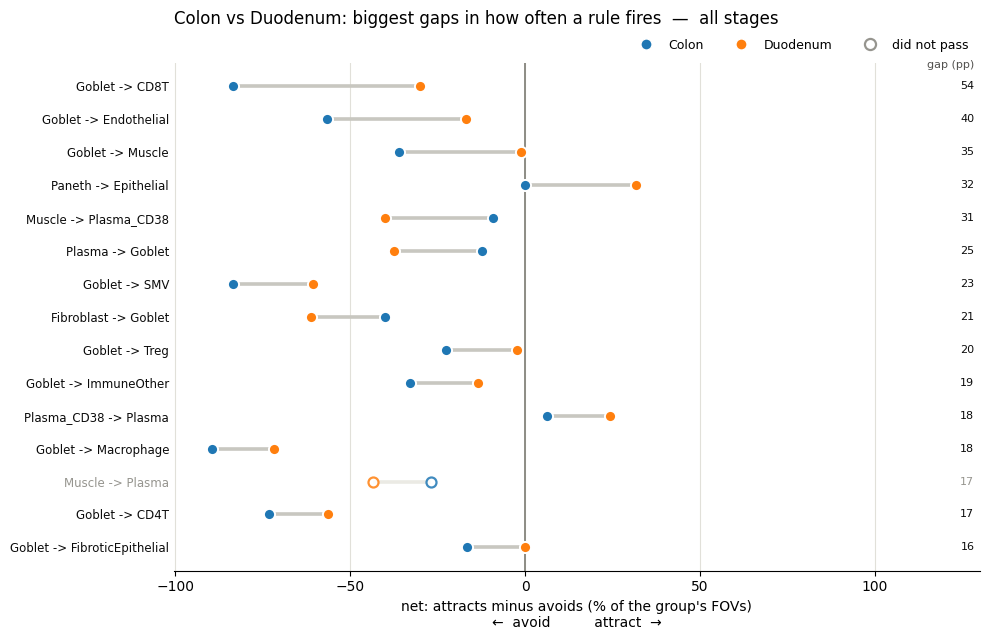

In [19]:
dv.plot_dumbbell(organ_comparision, 'Colon', 'Duodenum', scope='all stages', min_gap=MIN_GAP)

In [20]:
display(report_table(organ_comparision, 'Colon', 'Duodenum', metrics=organ_metrics))

,Colon net %,Duodenum net %,gap (pp),more in,Colon FOVs + / -,Duodenum FOVs + / -,FDR,passed,mean Confidence Colon,mean Confidence Duodenum,mean Lift Colon,mean Lift Duodenum
Clean_Rule,,,,,,,,,,,,
Goblet -> CD8T,-83.5,-30.0,53.5,Duodenum,0 / 81,0 / 51,0.0051,yes,0.19,0.30,0.38,0.48
Goblet -> Endothelial,-56.7,-17.1,39.6,Duodenum,0 / 55,0 / 29,0.0051,yes,0.06,0.10,0.19,0.26
Goblet -> Muscle,-36.1,-1.2,34.9,Duodenum,0 / 35,0 / 2,0.0051,yes,0.01,0.00,0.00,0.00
Paneth -> Epithelial,0.0,31.8,31.8,Duodenum,0 / 0,55 / 1,0.0051,yes,NaN,0.98,NaN,1.42
Muscle -> Plasma_CD38,-9.3,-40.0,30.7,Colon,0 / 9,0 / 68,0.0051,yes,0.05,0.09,0.02,0.05
Plasma -> Goblet,-12.4,-37.6,25.3,Colon,3 / 15,0 / 64,0.0051,yes,0.38,0.21,0.59,0.43
Goblet -> SMV,-83.5,-60.6,22.9,Duodenum,0 / 81,0 / 103,0.0073,yes,0.11,0.15,0.25,0.21
Fibroblast -> Goblet,-40.2,-61.2,21.0,Colon,1 / 40,0 / 104,0.0114,yes,0.29,0.19,0.57,0.43
Goblet -> Treg,-22.7,-2.4,20.3,Duodenum,0 / 22,0 / 4,0.0051,yes,0.11,0.10,0.31,0.39


### Stage against stage, inside each organ

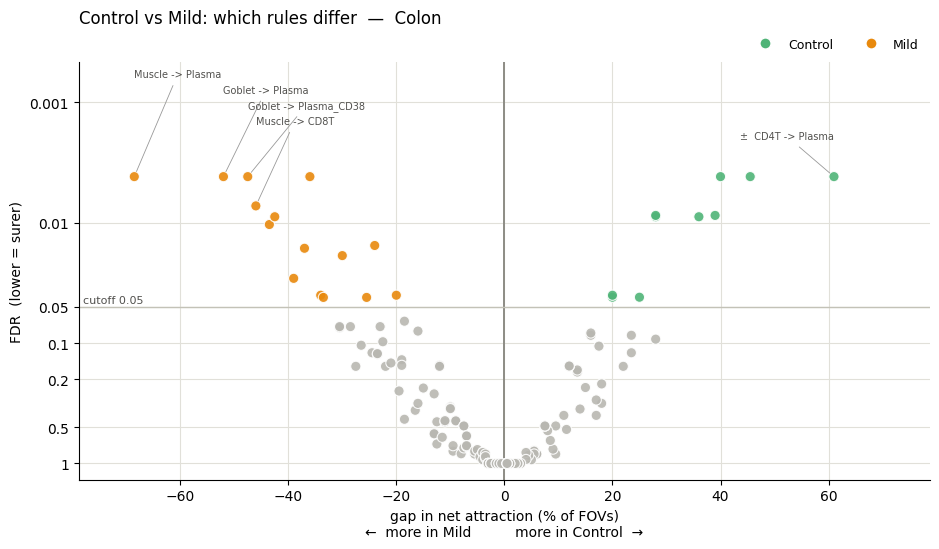

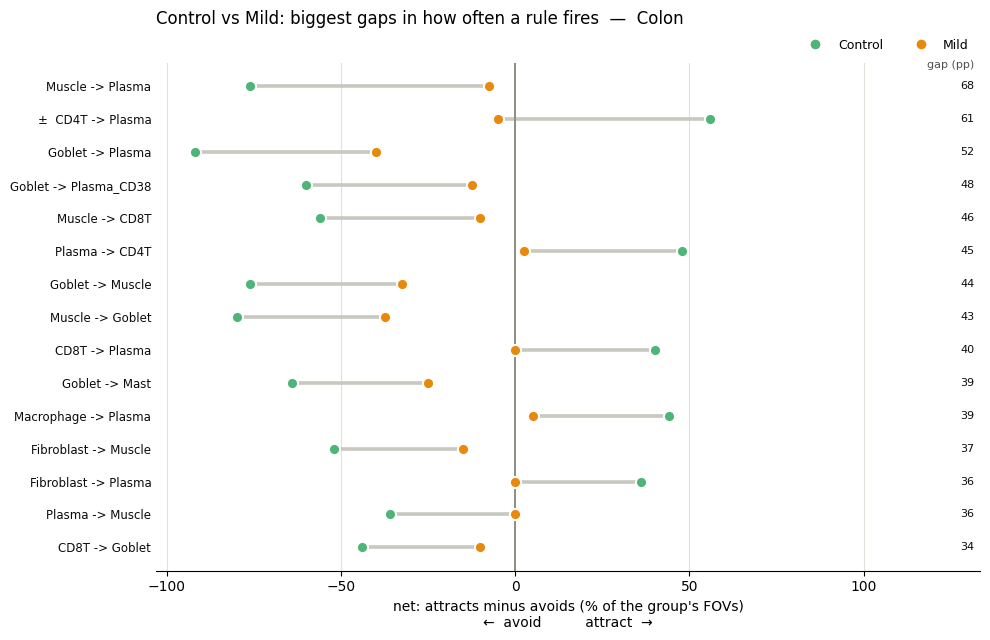

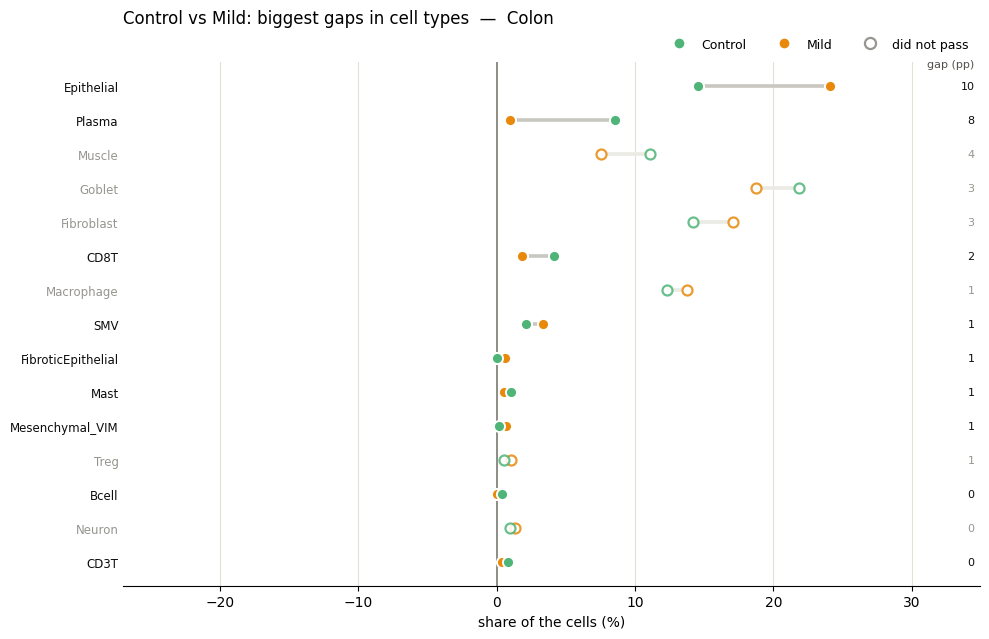

,Control net %,Mild net %,gap (pp),more in,Control FOVs + / -,Mild FOVs + / -,FDR,passed,mean Confidence Control,mean Confidence Mild,mean Lift Control,mean Lift Mild
Clean_Rule,,,,,,,,,,,,
Muscle -> Plasma,-76.0,-7.5,68.5,Mild,0 / 19,0 / 3,0.0041,yes,0.11,0.14,0.00,0.02
CD4T -> Plasma,56.0,-5.0,61.0,Control,14 / 0,0 / 2,0.0041,yes,0.77,0.62,1.28,1.12
Goblet -> Plasma,-92.0,-40.0,52.0,Mild,0 / 23,0 / 16,0.0041,yes,0.35,0.21,0.55,0.33
Goblet -> Plasma_CD38,-60.0,-12.5,47.5,Mild,0 / 15,0 / 5,0.0041,yes,0.14,0.12,0.31,0.14
Muscle -> CD8T,-56.0,-10.0,46.0,Mild,0 / 14,0 / 4,0.0072,yes,0.27,0.19,0.46,0.22
Plasma -> CD4T,48.0,2.5,45.5,Control,12 / 0,1 / 0,0.0041,yes,0.73,0.81,1.33,1.42
Goblet -> Muscle,-76.0,-32.5,43.5,Mild,0 / 19,0 / 13,0.0104,yes,0.00,0.03,0.00,0.00
Muscle -> Goblet,-80.0,-37.5,42.5,Mild,0 / 20,0 / 15,0.0089,yes,0.01,0.03,0.00,0.00
CD8T -> Plasma,40.0,0.0,40.0,Control,10 / 0,0 / 0,0.0041,yes,0.80,0.68,1.28,1.12


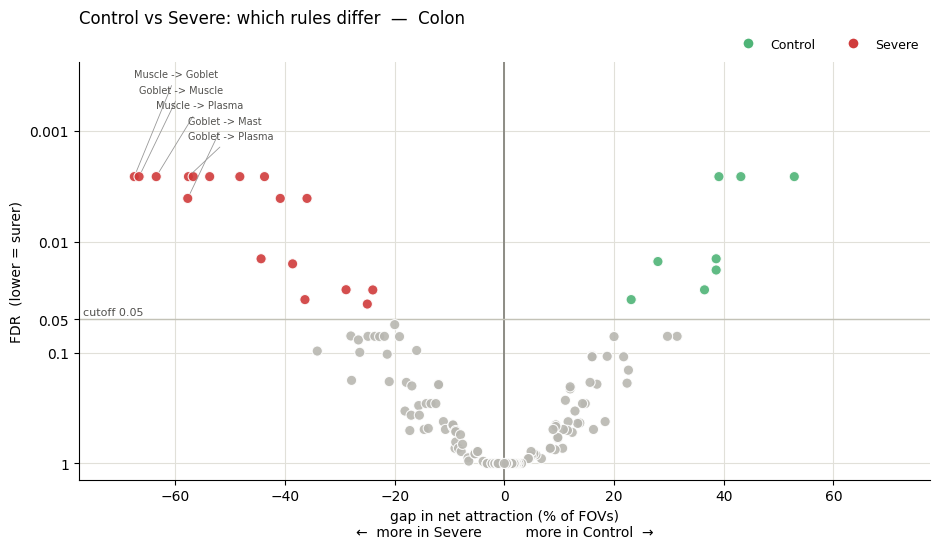

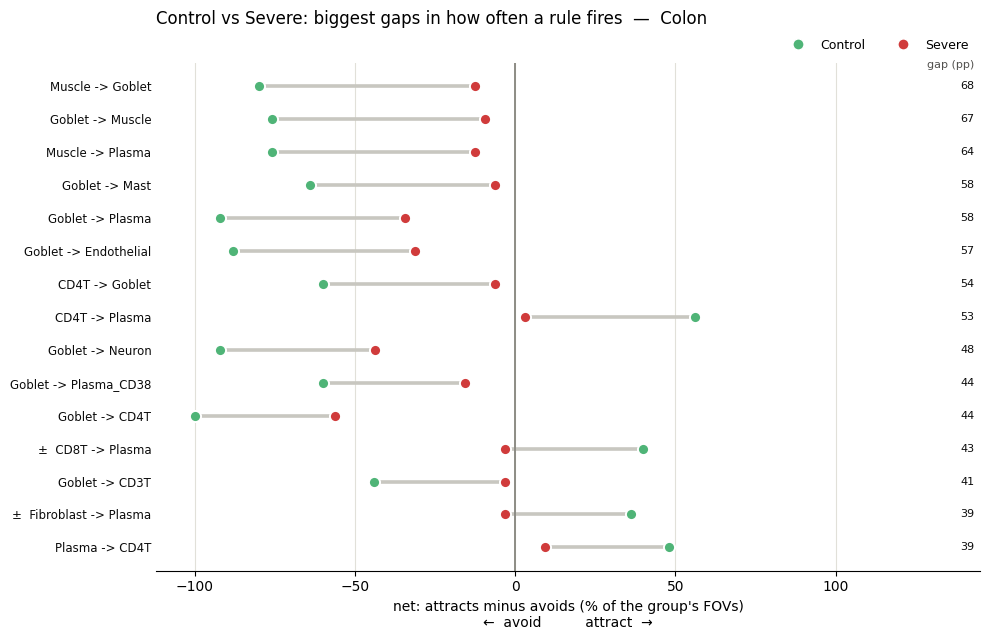

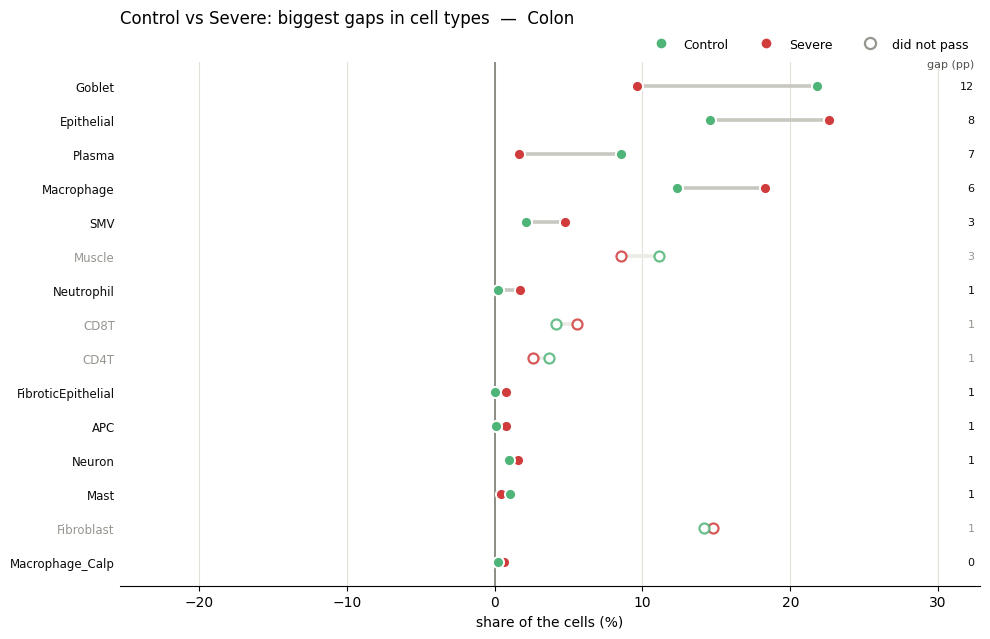

,Control net %,Severe net %,gap (pp),more in,Control FOVs + / -,Severe FOVs + / -,FDR,passed,mean Confidence Control,mean Confidence Severe,mean Lift Control,mean Lift Severe
Clean_Rule,,,,,,,,,,,,
Muscle -> Goblet,-80.0,-12.5,67.5,Severe,0 / 20,0 / 4,0.0026,yes,0.01,0.02,0.00,0.00
Goblet -> Muscle,-76.0,-9.4,66.6,Severe,0 / 19,0 / 3,0.0026,yes,0.00,0.00,0.00,0.00
Muscle -> Plasma,-76.0,-12.5,63.5,Severe,0 / 19,0 / 4,0.0026,yes,0.11,0.08,0.00,0.01
Goblet -> Mast,-64.0,-6.2,57.8,Severe,0 / 16,0 / 2,0.0041,yes,0.14,0.08,0.45,0.27
Goblet -> Plasma,-92.0,-34.4,57.6,Severe,0 / 23,0 / 11,0.0026,yes,0.35,0.10,0.55,0.19
Goblet -> Endothelial,-88.0,-31.2,56.8,Severe,0 / 22,0 / 10,0.0026,yes,0.08,0.05,0.26,0.18
CD4T -> Goblet,-60.0,-6.2,53.8,Severe,0 / 15,0 / 2,0.0026,yes,0.23,0.29,0.47,0.50
CD4T -> Plasma,56.0,3.1,52.9,Control,14 / 0,1 / 0,0.0026,yes,0.77,0.71,1.28,1.41
Goblet -> Neuron,-92.0,-43.8,48.3,Severe,0 / 23,0 / 14,0.0026,yes,0.09,0.10,0.26,0.12


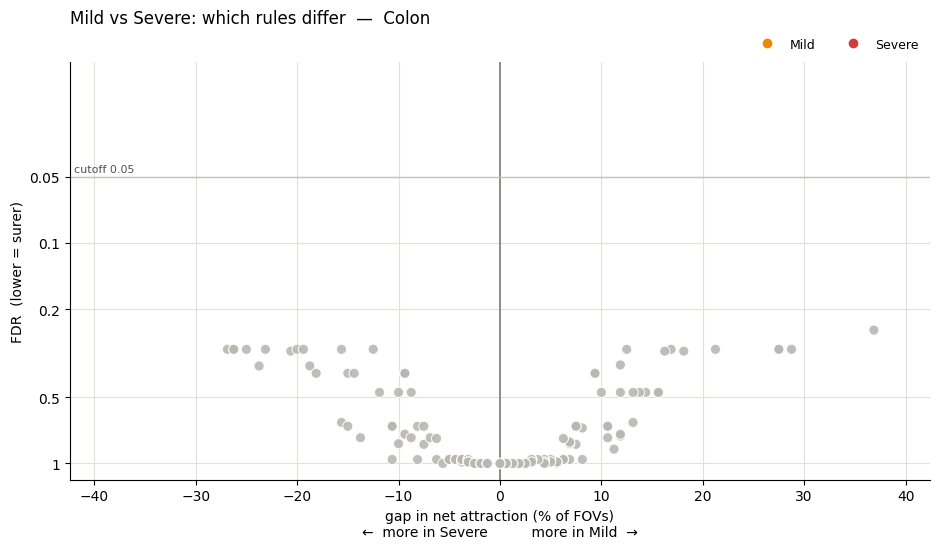

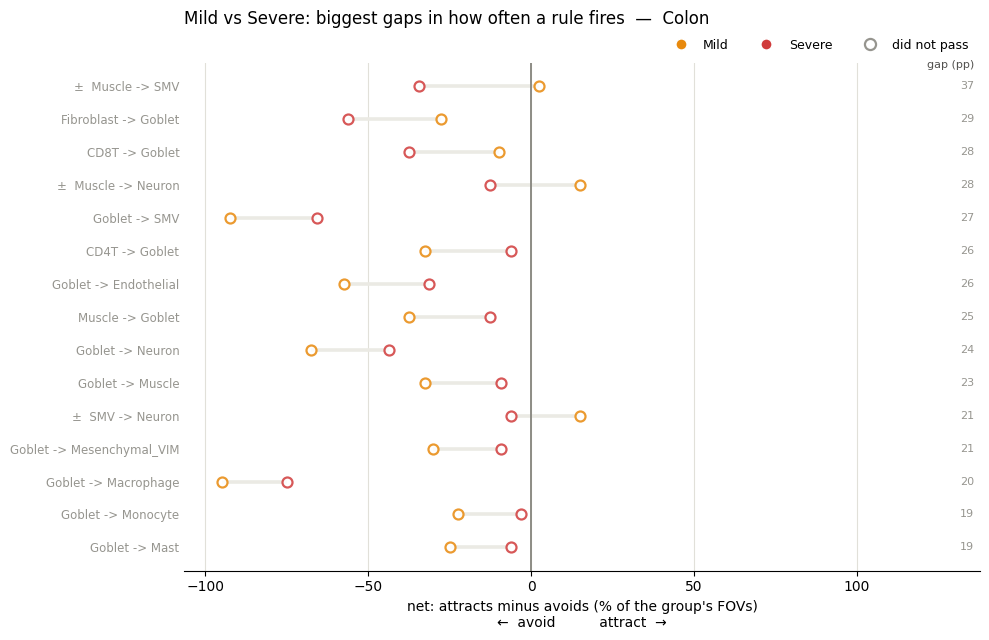

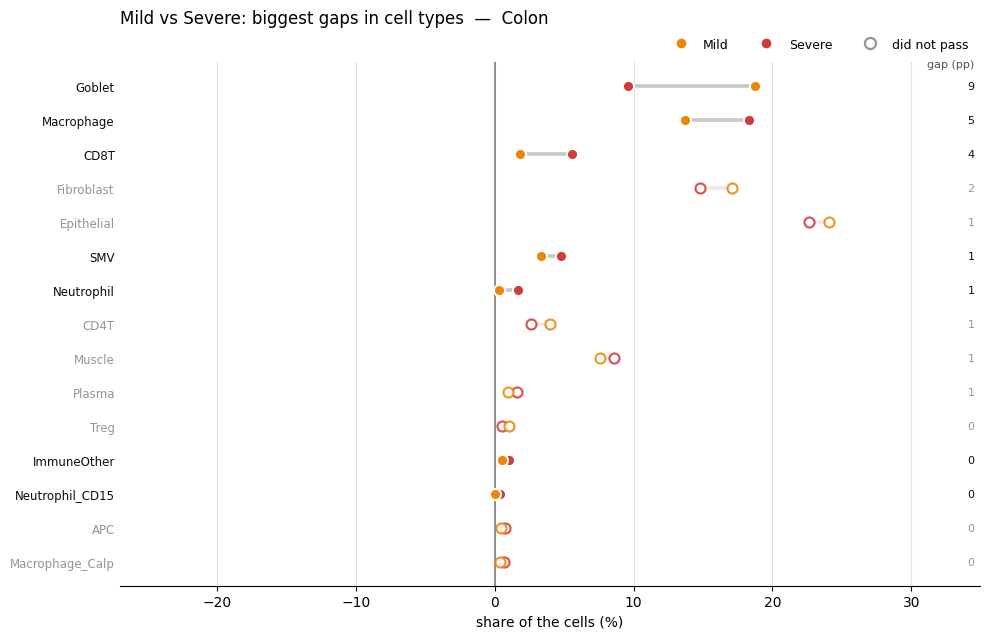

,Mild net %,Severe net %,gap (pp),more in,Mild FOVs + / -,Severe FOVs + / -,FDR,passed,mean Confidence Mild,mean Confidence Severe,mean Lift Mild,mean Lift Severe
Clean_Rule,,,,,,,,,,,,
Muscle -> SMV,2.5,-34.4,36.9,Mild,5 / 4,0 / 11,0.2484,no,0.41,0.28,0.51,0.44
Fibroblast -> Goblet,-27.5,-56.2,28.7,Mild,1 / 12,0 / 18,0.3035,no,0.22,0.21,0.45,0.47
CD8T -> Goblet,-10.0,-37.5,27.5,Mild,1 / 5,0 / 12,0.3035,no,0.27,0.20,0.62,0.50
Muscle -> Neuron,15.0,-12.5,27.5,Mild,6 / 0,1 / 5,0.3035,no,0.45,0.37,0.91,0.68
Goblet -> SMV,-92.5,-65.6,26.9,Severe,0 / 37,0 / 21,0.3035,no,0.14,0.12,0.22,0.20
CD4T -> Goblet,-32.5,-6.2,26.2,Severe,1 / 14,0 / 2,0.3035,no,0.22,0.29,0.41,0.50
Goblet -> Endothelial,-57.5,-31.2,26.2,Severe,0 / 23,0 / 10,0.3035,no,0.07,0.05,0.20,0.18
Muscle -> Goblet,-37.5,-12.5,25.0,Severe,0 / 15,0 / 4,0.3035,no,0.03,0.02,0.00,0.00
Goblet -> Neuron,-67.5,-43.8,23.8,Severe,0 / 27,0 / 14,0.3612,no,0.15,0.10,0.29,0.12


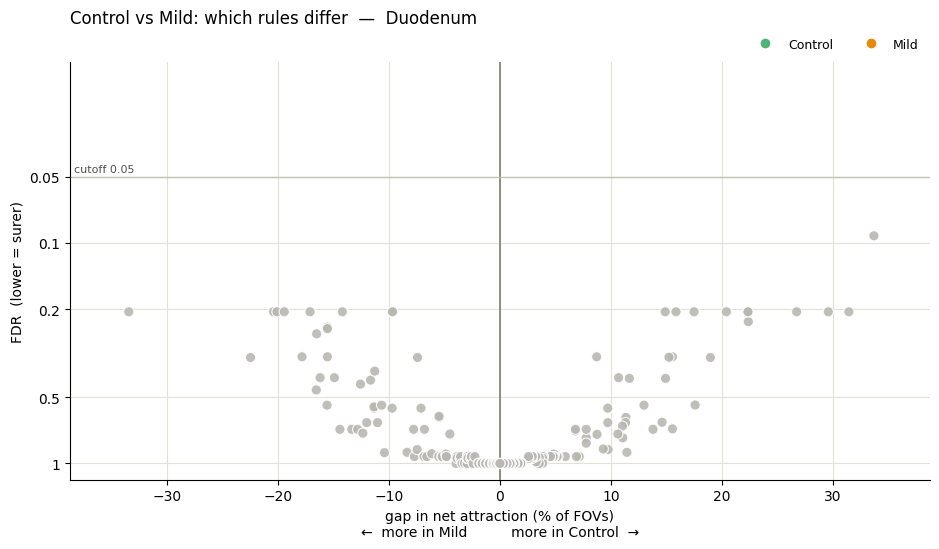

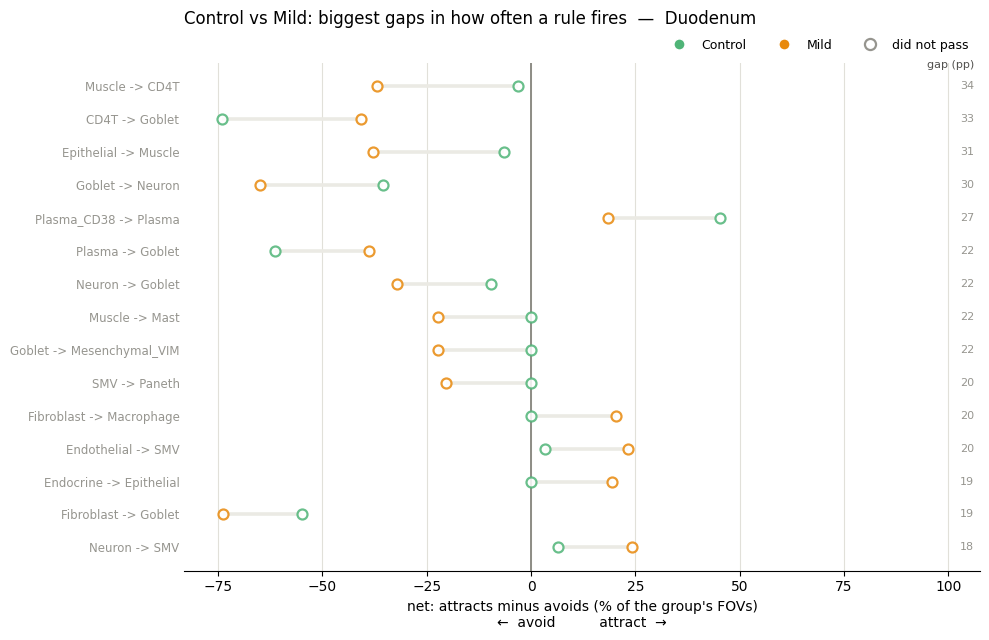

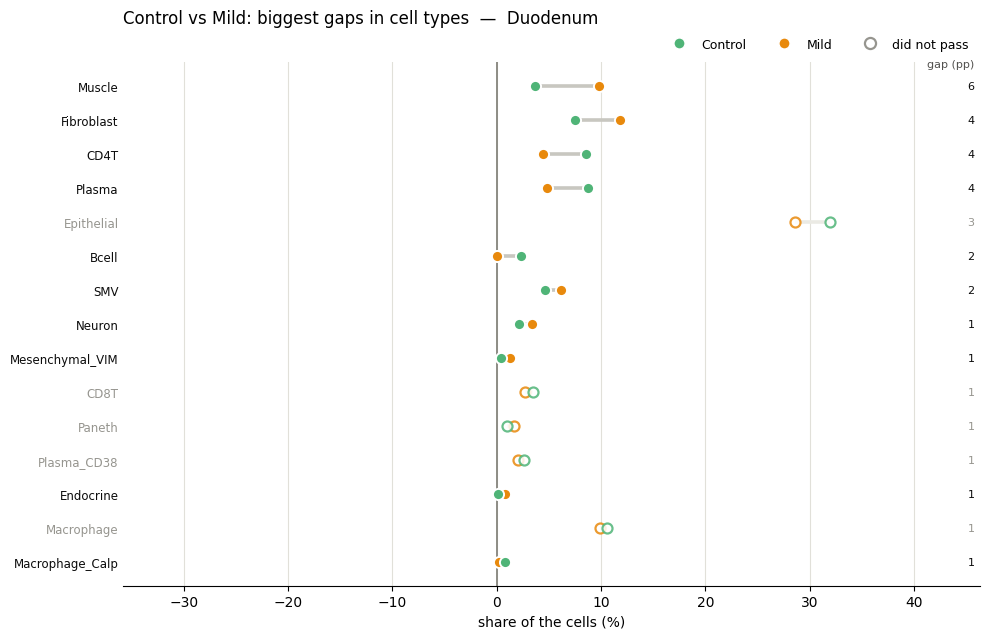

,Control net %,Mild net %,gap (pp),more in,Control FOVs + / -,Mild FOVs + / -,FDR,passed,mean Confidence Control,mean Confidence Mild,mean Lift Control,mean Lift Mild
Clean_Rule,,,,,,,,,,,,
Muscle -> CD4T,-3.2,-36.9,33.7,Control,3 / 4,0 / 38,0.0928,no,0.47,0.25,0.69,0.29
CD4T -> Goblet,-74.2,-40.8,33.4,Mild,0 / 23,0 / 42,0.2051,no,0.23,0.22,0.47,0.41
Epithelial -> Muscle,-6.5,-37.9,31.4,Control,0 / 2,0 / 39,0.2051,no,0.01,0.02,0.00,0.01
Goblet -> Neuron,-35.5,-65.0,29.6,Control,0 / 11,0 / 67,0.2051,no,0.09,0.15,0.26,0.29
Plasma_CD38 -> Plasma,45.2,18.4,26.7,Control,14 / 0,19 / 0,0.2051,no,0.92,0.87,1.34,1.58
Plasma -> Goblet,-61.3,-38.8,22.5,Mild,0 / 19,0 / 40,0.3307,no,0.29,0.23,0.57,0.43
Neuron -> Goblet,-9.7,-32.0,22.4,Control,0 / 3,0 / 33,0.2273,no,0.26,0.25,0.50,0.47
Goblet -> Mesenchymal_VIM,0.0,-22.3,22.3,Control,0 / 0,0 / 23,0.2051,no,0.02,0.07,0.00,0.10
Muscle -> Mast,0.0,-22.3,22.3,Control,2 / 2,1 / 24,0.2051,no,0.16,0.13,0.52,0.37


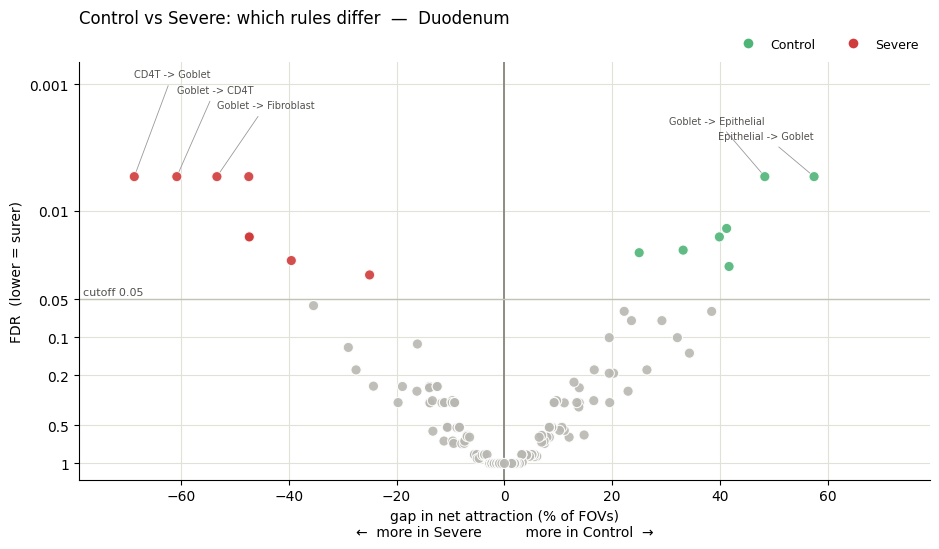

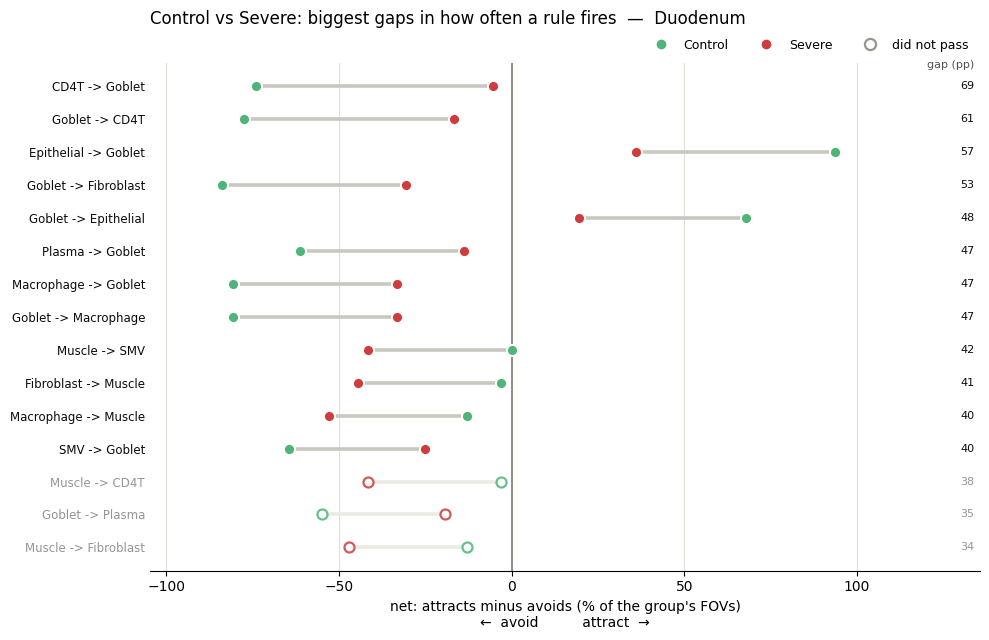

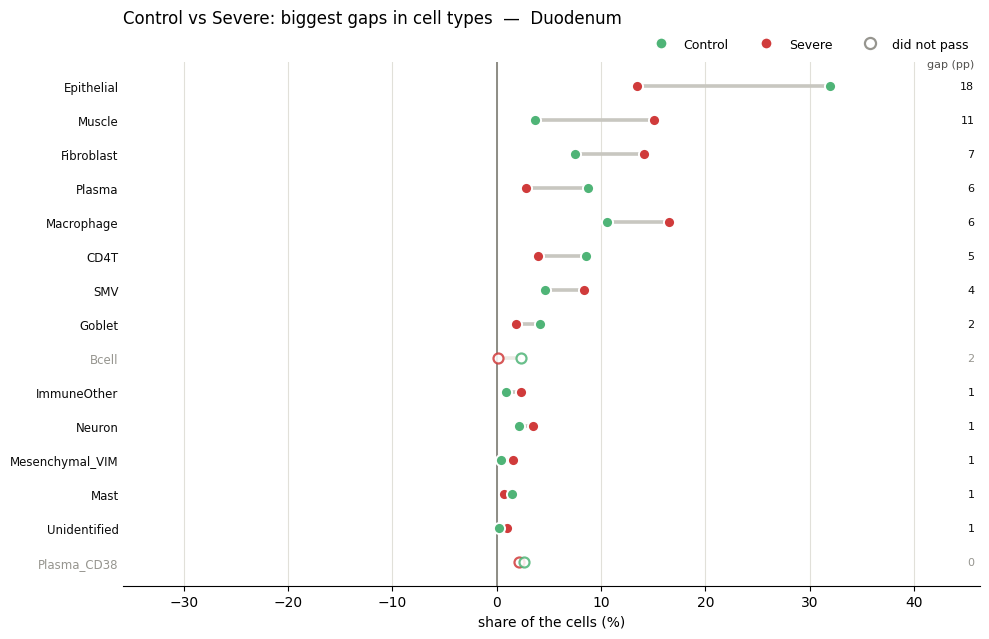

,Control net %,Severe net %,gap (pp),more in,Control FOVs + / -,Severe FOVs + / -,FDR,passed,mean Confidence Control,mean Confidence Severe,mean Lift Control,mean Lift Severe
Clean_Rule,,,,,,,,,,,,
CD4T -> Goblet,-74.2,-5.6,68.6,Severe,0 / 23,0 / 2,0.0054,yes,0.23,0.29,0.47,0.50
Goblet -> CD4T,-77.4,-16.7,60.8,Severe,0 / 24,0 / 6,0.0054,yes,0.25,0.10,0.40,0.14
Epithelial -> Goblet,93.5,36.1,57.4,Control,29 / 0,13 / 0,0.0054,yes,0.76,0.76,1.76,1.97
Goblet -> Fibroblast,-83.9,-30.6,53.3,Severe,0 / 26,0 / 11,0.0054,yes,0.39,0.36,0.51,0.37
Goblet -> Epithelial,67.7,19.4,48.3,Control,21 / 0,7 / 0,0.0054,yes,0.96,0.98,1.43,1.61
Plasma -> Goblet,-61.3,-13.9,47.4,Severe,0 / 19,0 / 5,0.0054,yes,0.29,0.19,0.57,0.30
Goblet -> Macrophage,-80.6,-33.3,47.3,Severe,0 / 25,0 / 12,0.0161,yes,0.45,0.35,0.53,0.39
Macrophage -> Goblet,-80.6,-33.3,47.3,Severe,0 / 25,0 / 12,0.0161,yes,0.26,0.22,0.54,0.46
Muscle -> SMV,0.0,-41.7,41.7,Control,3 / 3,1 / 16,0.0276,yes,0.34,0.28,0.66,0.44


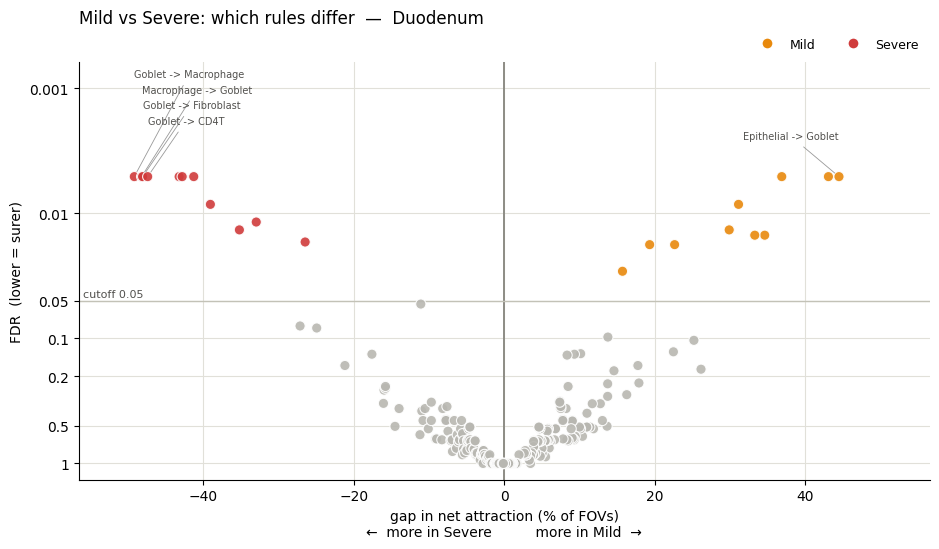

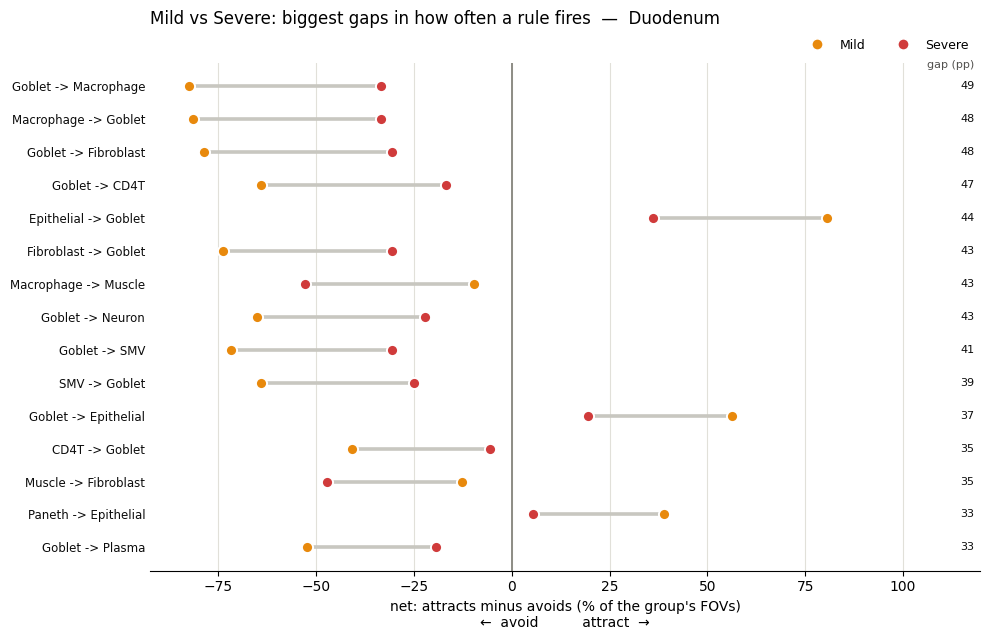

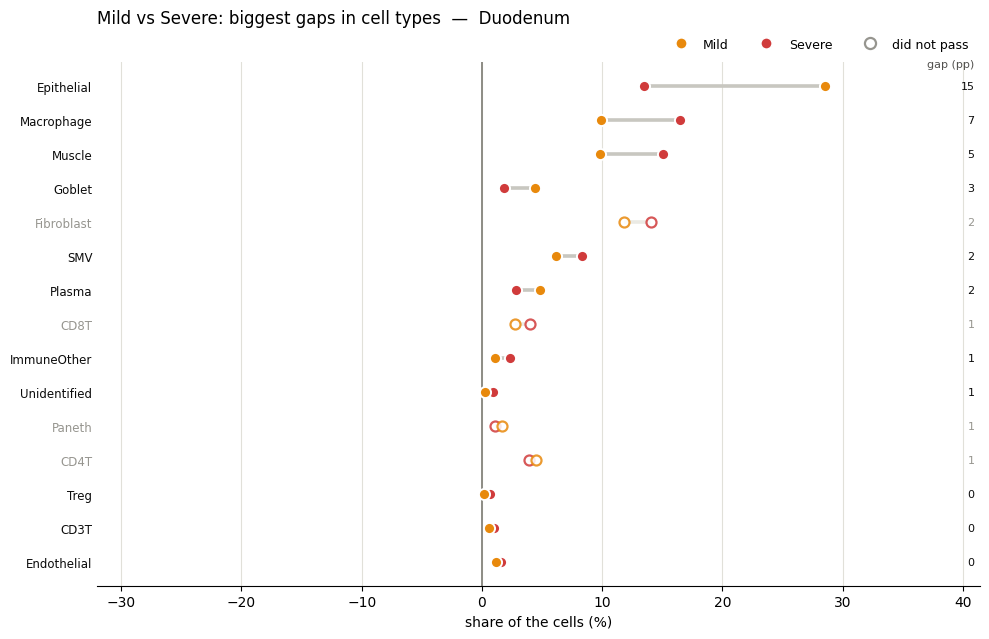

,Mild net %,Severe net %,gap (pp),more in,Mild FOVs + / -,Severe FOVs + / -,FDR,passed,mean Confidence Mild,mean Confidence Severe,mean Lift Mild,mean Lift Severe
Clean_Rule,,,,,,,,,,,,
Goblet -> Macrophage,-82.5,-33.3,49.2,Severe,0 / 85,0 / 12,0.0051,yes,0.36,0.35,0.42,0.39
Macrophage -> Goblet,-81.6,-33.3,48.2,Severe,0 / 84,0 / 12,0.0051,yes,0.24,0.22,0.47,0.46
Goblet -> Fibroblast,-78.6,-30.6,48.1,Severe,0 / 81,0 / 11,0.0051,yes,0.38,0.36,0.41,0.37
Goblet -> CD4T,-64.1,-16.7,47.4,Severe,0 / 66,0 / 6,0.0051,yes,0.18,0.10,0.30,0.14
Epithelial -> Goblet,80.6,36.1,44.5,Mild,83 / 0,13 / 0,0.0051,yes,0.76,0.76,1.83,1.97
Fibroblast -> Goblet,-73.8,-30.6,43.2,Severe,0 / 76,0 / 11,0.0051,yes,0.22,0.21,0.45,0.47
Macrophage -> Muscle,-9.7,-52.8,43.1,Mild,0 / 10,0 / 19,0.0051,yes,0.15,0.14,0.61,0.58
Goblet -> Neuron,-65.0,-22.2,42.8,Severe,0 / 67,0 / 8,0.0051,yes,0.15,0.10,0.29,0.12
Goblet -> SMV,-71.8,-30.6,41.3,Severe,0 / 74,0 / 11,0.0051,yes,0.14,0.12,0.22,0.20


In [21]:
for key, comparison in stage_comparisions.items():
    organ, stage_a, stage_b = key
    dv.plot_volcano(comparison, stage_a, stage_b, scope=organ, min_gap=MIN_GAP)
    dv.plot_dumbbell(comparison, stage_a, stage_b, scope=organ, min_gap=MIN_GAP)
    dv.plot_dumbbell(stage_cells[key], stage_a, stage_b, scope=organ, top_n=15,
                     value_label='share of the cells (%)', what='cell types')
    display(report_table(comparison, stage_a, stage_b, metrics=stage_metrics))


## Trend Logic

In [22]:
def stage_nets(rule_presence_matrix, fovs_by_stage):
    """Rules x stages: each rule's net in each stage, in severity order.
    fovs_by_stage : {'Control': [...], 'Mild': [...], 'Severe': [...]}
    """

    nets = {stage: group_values(rule_presence_matrix, fovs).mean(axis=1) for stage, fovs in fovs_by_stage.items()}
    return pd.DataFrame(nets, index=rule_presence_matrix.index)

stage_nets(rule_presence_matrix,
           {s: fovs_for(organ='Colon', stage=s) for s in STAGE_ORDER}).head()

,Control,Mild,Severe
Clean_Rule,,,
APC -> CD4T,0.0,0.050,0.0000
APC -> CD8T,0.0,0.025,0.0625
APC -> Endocrine,0.0,0.000,0.0000
APC -> Endothelial,0.0,0.000,0.0000
APC -> Fibroblast,0.0,0.000,0.0000


In [23]:
def compare_stages(rule_presence_matrix, fovs_by_stage, min_fovs=MIN_FOVS_TOTAL):
    """Which rules move steadily with severity: slope per stage + FDR, one row per rule."""

    nets = stage_nets(rule_presence_matrix, fovs_by_stage)

    # One flat FOV list, kept in stage order, so the weights below line up with it.
    fovs = [fov for stage_fovs in fovs_by_stage.values() for fov in stage_fovs]
    values = group_values(rule_presence_matrix, fovs)

    keep = (values != 0).sum(1) >= min_fovs
    values, nets = values[keep], nets.loc[keep]

    print(f"Compare stages - {values.shape[0]} rules with at least {min_fovs} FOVs across the stages.")
    # print("Values: ", values[:3])
    # print("Nets: ", nets.head())

    # Control -> 0, Mild -> 1, Severe -> 2, one per FOV, in the same order as `fovs`.
    ranks = np.concatenate([np.full(len(stage_fovs), i, dtype=float) 
                            for i, stage_fovs in enumerate(fovs_by_stage.values())])

    # print("Compare stages - ranks: ", ranks)

    # Move the middle stage to zero, so a flat rule cancels out to nothing
    centered = ranks - ranks.mean()

    # Scale them, so the score comes out as net per stage step and not some raw total.
    weights = centered / np.sum(centered ** 2)

    # Every FOV's value times its weight: the slope of a straight line through the stages.
    slope = values @ weights
    # print("Compare stages - slopes: ", slope)

    # Same permutation engine as the pairwise test, with the stage weights instead.
    p_values = chance_of(values, weights, slope)

    # One FDR correction over all the rules tested in this organ.
    fdr = multipletests(p_values, method='fdr_bh')[1]

    # No zigzag: every step goes the same way, so the change is gradual and not a jump.
    steps = np.diff(nets.to_numpy(dtype=float), axis=1)
    steady = (steps >= 0).all(axis=1) | (steps <= 0).all(axis=1)

    # The three stage numbers first, then what the test made of them.
    result = nets.add_prefix('net_')
    result['slope'] = slope
    result['steady'] = steady
    result['p_value'] = p_values
    result['fdr'] = fdr

    return result.sort_values('slope', key=abs, ascending=False)  # steepest moves first

In [24]:
def trend_table(trend, stages, top_n=8, fdr_threshold=FDR_THRESHOLD):
    """The rules the trend plot draws, as numbers - the same top few each way."""
    moved = trend[trend['fdr'] <= fdr_threshold]
    rows = pd.concat([moved[moved['slope'] > 0].head(top_n),
                      moved[moved['slope'] < 0].head(top_n)])

    table = (rows[[f'net_{stage}' for stage in stages]] * 100).round(0)
    table.columns = [f'{stage} net %' for stage in stages]
    table['pp per stage'] = (rows['slope'] * 100).round(0)
    table['direction'] = np.where(rows['slope'] > 0, 'climbing', 'fading')
    table['same way every step'] = rows['steady']
    table['FDR'] = rows['fdr'].round(4)
    return table

In [25]:
stage_trends, summary = {}, []

for organ in ORGAN_ORDER:
    stage_fovs = {stage: fovs_for(organ=organ, stage=stage) for stage in STAGE_ORDER}
    trend = compare_stages(rule_presence_matrix, stage_fovs)
    stage_trends[organ] = trend

    moved = trend['fdr'] <= FDR_THRESHOLD
    summary.append({'organ': organ,
                    **{f'{stage} FOVs': len(fovs) for stage, fovs in stage_fovs.items()},
                    'rules tested': len(trend),
                    'moved with severity': moved.sum(),
                    'climbing': (moved & (trend['slope'] > 0)).sum(),
                    'fading': (moved & (trend['slope'] < 0)).sum(),
                    'steady all the way': (moved & trend['steady']).sum()})

display(pd.DataFrame(summary).set_index('organ'))

Compare stages - 174 rules with at least 3 FOVs across the stages.
Compare stages - 274 rules with at least 3 FOVs across the stages.


,Control FOVs,Mild FOVs,Severe FOVs,rules tested,moved with severity,climbing,fading,steady all the way
organ,,,,,,,,
Colon,25,40,32,174,38,25,13,29
Duodenum,31,103,36,274,17,9,8,13


In [26]:
stage_trends, stage_cell_trends = {}, {}

for organ in ORGAN_ORDER:
    stage_fovs = {stage: fovs_for(organ=organ, stage=stage) for stage in STAGE_ORDER}
    stage_trends[organ] = compare_stages(rule_presence_matrix, stage_fovs)
    stage_cell_trends[organ] = compare_stages(cell_matrix, stage_fovs)


Compare stages - 174 rules with at least 3 FOVs across the stages.
Compare stages - 31 rules with at least 3 FOVs across the stages.
Compare stages - 274 rules with at least 3 FOVs across the stages.
Compare stages - 32 rules with at least 3 FOVs across the stages.


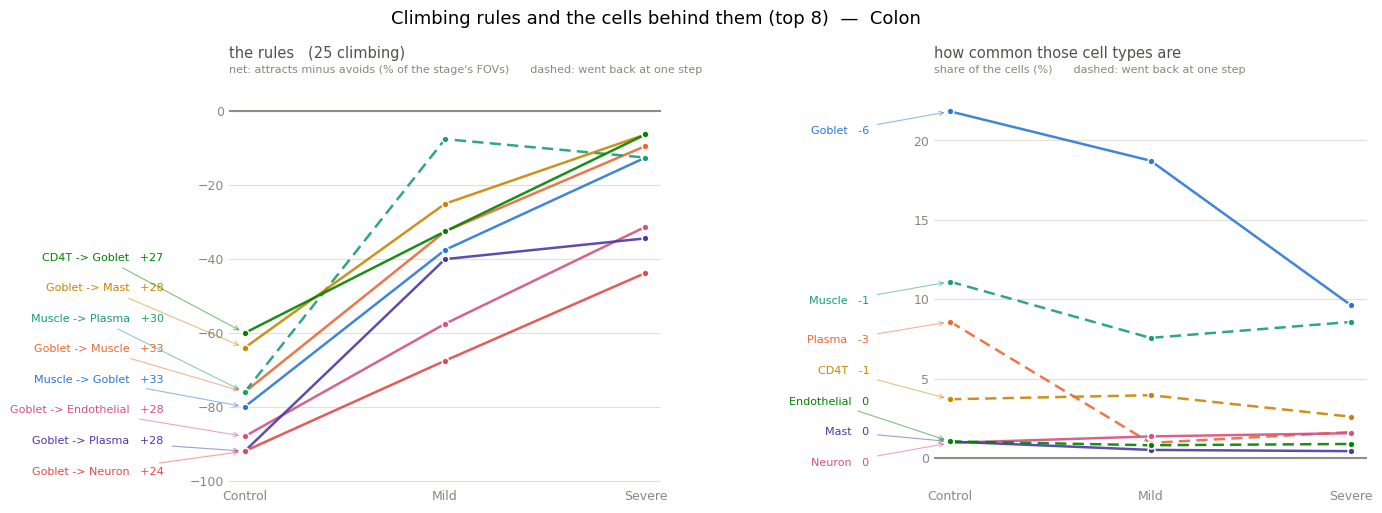

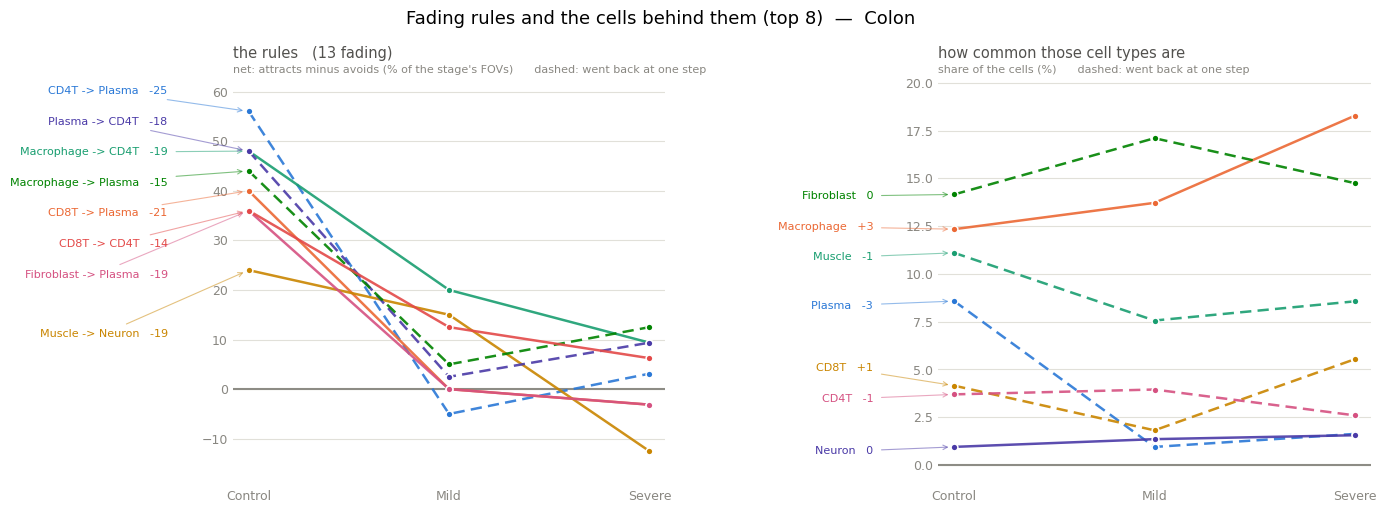

,Control net %,Mild net %,Severe net %,pp per stage,direction,same way every step,FDR
Clean_Rule,,,,,,,
Muscle -> Goblet,-80.0,-38.0,-12.0,33.0,climbing,True,0.0025
Goblet -> Muscle,-76.0,-32.0,-9.0,33.0,climbing,True,0.0025
Muscle -> Plasma,-76.0,-8.0,-12.0,30.0,climbing,False,0.0025
Goblet -> Mast,-64.0,-25.0,-6.0,28.0,climbing,True,0.0025
Goblet -> Endothelial,-88.0,-57.0,-31.0,28.0,climbing,True,0.0025
Goblet -> Plasma,-92.0,-40.0,-34.0,28.0,climbing,True,0.0025
CD4T -> Goblet,-60.0,-32.0,-6.0,27.0,climbing,True,0.0025
Goblet -> Neuron,-92.0,-68.0,-44.0,24.0,climbing,True,0.0043
CD4T -> Plasma,56.0,-5.0,3.0,-25.0,fading,False,0.0025


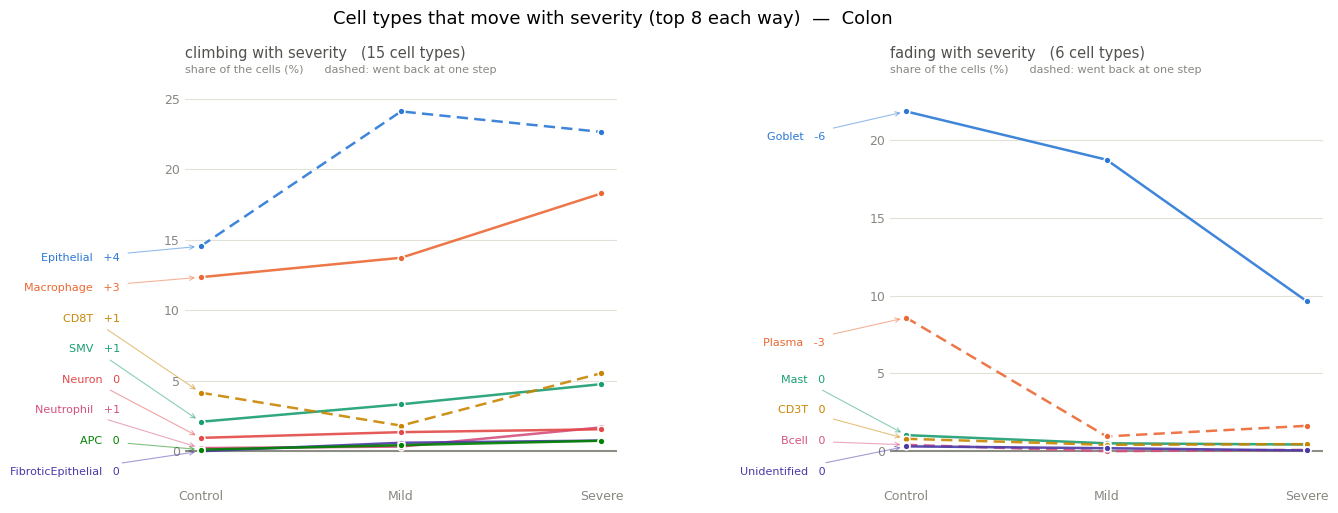

,Control net %,Mild net %,Severe net %,pp per stage,direction,same way every step,FDR
cell type,,,,,,,
Epithelial,15.0,24.0,23.0,4.0,climbing,False,0.0072
Macrophage,12.0,14.0,18.0,3.0,climbing,True,0.0027
SMV,2.0,3.0,5.0,1.0,climbing,True,0.0012
CD8T,4.0,2.0,6.0,1.0,climbing,False,0.0263
Neutrophil,0.0,0.0,2.0,1.0,climbing,True,0.0012
FibroticEpithelial,0.0,1.0,1.0,0.0,climbing,True,0.0056
APC,0.0,0.0,1.0,0.0,climbing,True,0.0080
Neuron,1.0,1.0,2.0,0.0,climbing,True,0.0265
Goblet,22.0,19.0,10.0,-6.0,fading,True,0.0012


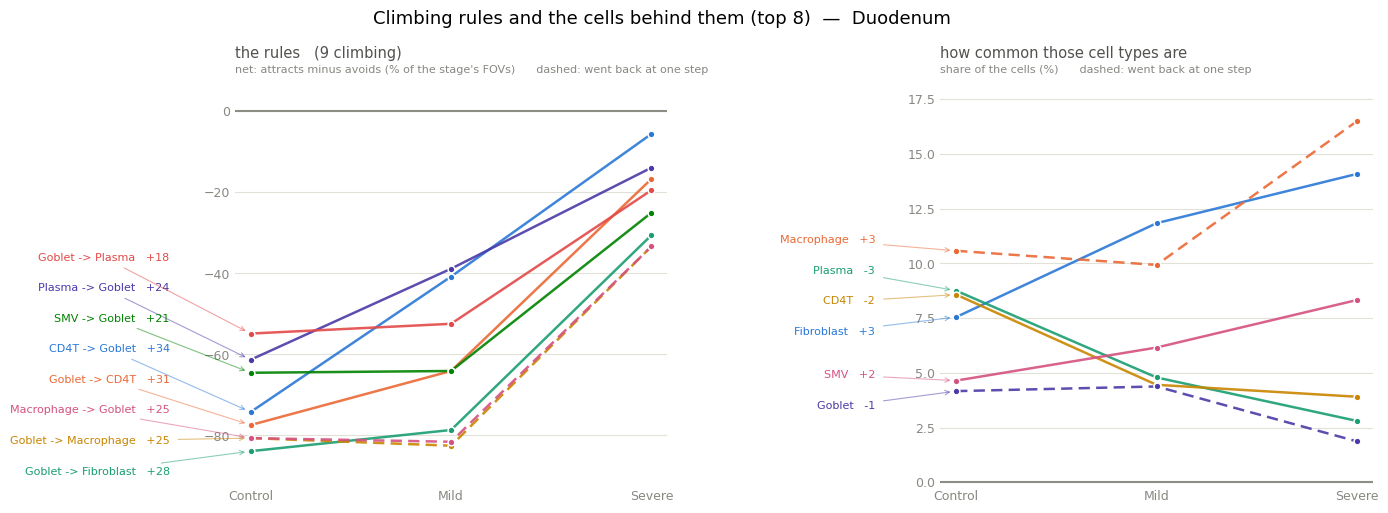

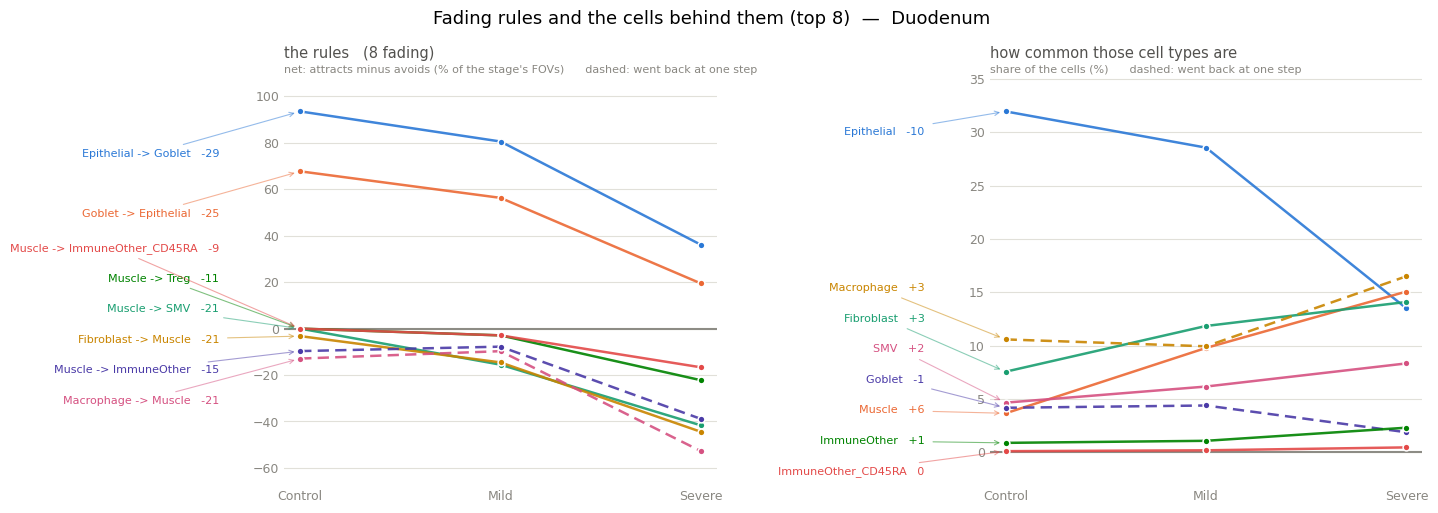

,Control net %,Mild net %,Severe net %,pp per stage,direction,same way every step,FDR
Clean_Rule,,,,,,,
CD4T -> Goblet,-74.0,-41.0,-6.0,34.0,climbing,True,0.0055
Goblet -> CD4T,-77.0,-64.0,-17.0,31.0,climbing,True,0.0055
Goblet -> Fibroblast,-84.0,-79.0,-31.0,28.0,climbing,True,0.0055
Goblet -> Macrophage,-81.0,-83.0,-33.0,25.0,climbing,False,0.0055
Macrophage -> Goblet,-81.0,-82.0,-33.0,25.0,climbing,False,0.0091
Plasma -> Goblet,-61.0,-39.0,-14.0,24.0,climbing,True,0.0055
SMV -> Goblet,-65.0,-64.0,-25.0,21.0,climbing,True,0.0091
Goblet -> Plasma,-55.0,-52.0,-19.0,18.0,climbing,True,0.0451
Epithelial -> Goblet,94.0,81.0,36.0,-29.0,fading,True,0.0055


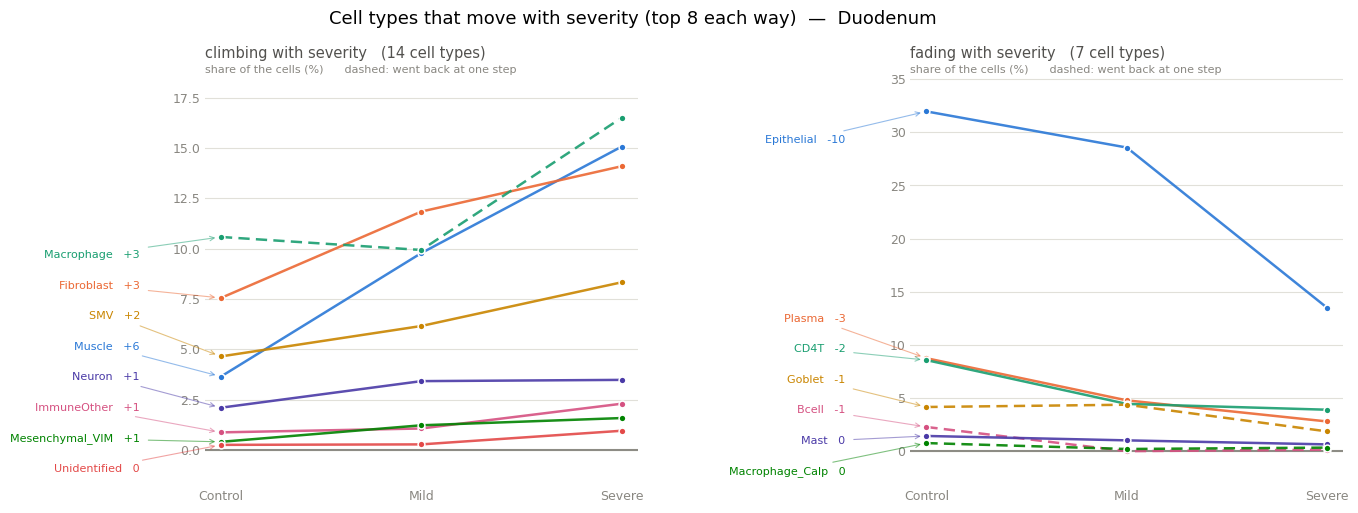

,Control net %,Mild net %,Severe net %,pp per stage,direction,same way every step,FDR
cell type,,,,,,,
Muscle,4.0,10.0,15.0,6.0,climbing,True,0.0005
Fibroblast,8.0,12.0,14.0,3.0,climbing,True,0.0005
Macrophage,11.0,10.0,17.0,3.0,climbing,False,0.0005
SMV,5.0,6.0,8.0,2.0,climbing,True,0.0005
ImmuneOther,1.0,1.0,2.0,1.0,climbing,True,0.0005
Neuron,2.0,3.0,3.0,1.0,climbing,True,0.0301
Mesenchymal_VIM,0.0,1.0,2.0,1.0,climbing,True,0.0005
Unidentified,0.0,0.0,1.0,0.0,climbing,True,0.0010
Epithelial,32.0,29.0,13.0,-10.0,fading,True,0.0005


In [27]:
for organ in ORGAN_ORDER:
    for rising in (True, False):
        dv.plot_rules_with_cells(stage_trends[organ], stage_cell_trends[organ],
                                 STAGE_ORDER, rising=rising, scope=organ)

    display(trend_table(stage_trends[organ], STAGE_ORDER))

    dv.plot_trend(stage_cell_trends[organ], STAGE_ORDER, scope=organ,
                  what='Cell types', value_label='share of the cells (%)')
    display(trend_table(stage_cell_trends[organ], STAGE_ORDER))